# *Digit recognition NN from scratch project*


**Set-up stuff**



In [1]:
#import needed packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#importing mnist database and splitting into training and testing data
mnist_train_df = pd.read_csv('/content/sample_data/mnist_train_small.csv')
mnist_test_df = pd.read_csv('/content/sample_data/mnist_test.csv')
x_train = np.array(mnist_train_df.iloc[0:, 1:]) # set up training data x and then transpose so it is in form 784xm
x_train = x_train.T
x_train = x_train/255.0  # Normalize pixel values to 0-1
x_test = np.array(mnist_test_df.iloc[0:, 1:]) #same for testing data
x_test = x_test.T
x_test = x_test/255.0  # Normalize pixel values to 0-1
y_train = np.array(mnist_train_df.iloc[0:, 0]) # set up labels
y_test = np.array(mnist_test_df.iloc[0:, 0])
single_test = np.array(mnist_train_df.iloc[0, 1:])

#Producing initial random parameters
def initial_params():
  n0 = 784 #numbers of nodes in each layer
  n1 = 128 #nodes in hidden layer
  n2 = 10 #nodes in output layer
  w1 = np.random.randn(n1,n0)*np.sqrt(2/n0) #generating weights with gaussian distribution and multiplying by sqrt(2/n) (He initialisation for ReLu)
  w2 = np.random.randn(n2,n1)*np.sqrt(2/n1) #w1 is n1x784 and w2 is 10xn1
  b1 = np.zeros((n1, 1)) #initialising biases all as zeros, as column vector (n1, 1)
  b2 = np.zeros((n2, 1)) #initialising biases all as zeros, as column vector (n2, 1)
  return w1, b1, w2, b2 # Return the initialized parameters

w1, b1, w2, b2 = initial_params()

#defining ReLu and Softmaxx activation functions
def relu(z):
  return np.maximum(0, z)
def softmaxx(z):
  # Numerically stable softmax: subtract max for each example before exponentiating
  exp_z = np.exp(z - np.max(z, axis=0, keepdims=True))
  return exp_z / np.sum(exp_z, axis=0, keepdims=True)



**Forward and back prop**





In [2]:
def forwardprop(x,w1,b1,w2,b2):
  z1 = w1.dot(x)+b1 #returns z1 as n1xm matrix
  a1 = relu(z1)
  z2 = w2.dot(a1)+b2 #returs z2 as 10xm matrix
  a2 = softmaxx(z2) #
  return z1,a1,z2,a2


#onehot conversion for y for backprop where y is array of all labels of images
def onehot(y):
  Y = np.zeros((y.size,10)) #initialising zeros matrix, one row of 10 for each label
  Y[np.arange(y.size),y] = 1 #sets spot in row that corresponds to label to one
  return Y.T

#defining derivitaves of ReLU activation functions for use in backprop
def relu_diff(x):
  return x>0

def backprop(x,z1,a1,z2,a2,w1,b1,w2,b2,y):
  Y = onehot(y) # finds labels and converts them to onehot form
  m = y.size

  dz2 = a2-Y #(10xm)
  dw2 = (dz2.dot(a1.T))/m #(10xm)(mxn1) gives (10xn1)
  db2 = (dz2.sum(axis = 1, keepdims = True))/m #averages error over biases to give (10x1) matrix

  dz1 = (w2.T.dot(dz2)*relu_diff(z1)) #(60x10)(10xm) gives (60xm)
  dw1 = (dz1.dot(x.T))/m #(60xm)(mx784) gives (60x784)
  db1 = (dz1.sum(axis = 1, keepdims = True))/m #averages error over biases to give (n1x1) matrix

  return dw1,db1,dw2,db2

def update_params(w1,dw1,b1,db1,w2,dw2,b2,db2,a):    #a = learning rate
  w1 -= a*dw1
  b1 -= a*db1
  w2 -= a*dw2
  b2 -= a*db2
  return w1,b1,w2,b2

**Training and testing: gradient descent**

In [3]:
#defining functions to give predictions and accuracy

def get_predictions(a2):
  return np.argmax(a2,0) #returns index of maximum value of each column in a2, returns an array of m predictions

def accuracy(y,predictions):
  correct = y == predictions # correct is array of booleans of whether the prediction equals label
  return np.sum(correct)/y.size #sum finds amount of true elements in correct

def grad_descent(x,y,a,its):
  w1,b1,w2,b2 = initial_params()
  for i in range(its):
    z1,a1,z2,a2 = forwardprop(x,w1,b1,w2,b2)
    dw1,db1,dw2,db2 = backprop(x,z1,a1,z2,a2,w1,b1,w2,b2,y)
    w1,b1,w2,b2 = update_params(w1,dw1,b1,db1,w2,dw2,b2,db2,a)
    if i%10 == 0:
      predictions = get_predictions(a2)
      print(f'iteration {i}: accuracy = {accuracy(y,predictions)}')
  return w1,b1,w2,b2

**Backprop and gradient descent but this time with mini batches for more efficient training**

In [4]:
def split_to_batches(x,y,n):
  m = y.size
  x_batches = np.split(x,range(n, m, n), axis=1)
  y_batches = np.split(y,range(n, m, n))
  return x_batches, y_batches

def gradient_descent_batches(x, y, a, its, n):
  w1,b1,w2,b2 = initial_params()
  x_batches, y_batches = split_to_batches(x,y,n)
  for i in range(its):
    for x_batch, y_batch in zip(x_batches,y_batches):
      z1,a1,z2,a2 = forwardprop(x_batch,w1,b1,w2,b2)
      dw1,db1,dw2,db2 = backprop(x_batch,z1,a1,z2,a2,w1,b1,w2,b2,y_batch)
      w1,b1,w2,b2 = update_params(w1,dw1,b1,db1,w2,dw2,b2,db2,a)
    if i%10 == 0:
      z1,a1,z2,a2 = forwardprop(x,w1,b1,w2,b2)
      predictions = get_predictions(a2)
      print(f'iteration {i}: accuracy = {accuracy(y,predictions)}')
  return w1,b1,w2,b2





# Actually training the model


In [ ]:
w1,b1,w2,b2 = grad_descent(x_train,y_train,0.1,200)

iteration 0: accuracy = 0.09810490524526226
iteration 10: accuracy = 0.648482424121206
iteration 20: accuracy = 0.7696884844242212
iteration 30: accuracy = 0.8145407270363518
iteration 40: accuracy = 0.8369918495924796
iteration 50: accuracy = 0.8514425721286064
iteration 60: accuracy = 0.8610930546527327
iteration 70: accuracy = 0.8677933896694835
iteration 80: accuracy = 0.8740437021851093
iteration 90: accuracy = 0.8786939346967348
iteration 100: accuracy = 0.8833441672083604
iteration 110: accuracy = 0.8866943347167359
iteration 120: accuracy = 0.8903445172258613
iteration 130: accuracy = 0.8923946197309865
iteration 140: accuracy = 0.8938446922346117
iteration 150: accuracy = 0.896044802240112
iteration 160: accuracy = 0.8975448772438622
iteration 170: accuracy = 0.8987449372468623
iteration 180: accuracy = 0.9002450122506125
iteration 190: accuracy = 0.9015450772538627


# Training with bactches

In [5]:
w1,b1,w2,b2 = gradient_descent_batches(x_train,y_train,0.1,70,64)

iteration 0: accuracy = 0.9031451572578629
iteration 10: accuracy = 0.9774488724436222
iteration 20: accuracy = 0.992049602480124
iteration 30: accuracy = 0.9971498574928747
iteration 40: accuracy = 0.9988999449972499
iteration 50: accuracy = 0.99969998499925
iteration 60: accuracy = 1.0


# Testing trained models

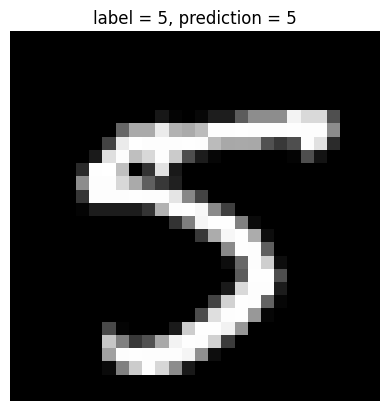

In [9]:
def single_test(index,x_test,y_test,w1,b1,w2,b2): #test model over a single example to visualise
  image_data = x_test[0:, index]
  image_data = image_data.reshape(784,1)
  image_label = y_test[index]
  z1,a1,z2,a2 = forwardprop(image_data,w1,b1,w2,b2)
  prediction = np.argmax(a2)
  image_pixels = image_data.reshape(28,28)
  plt.imshow(image_pixels, cmap = 'gray')
  plt.title(f'label = {image_label}, prediction = {prediction}')
  plt.axis('off')
  plt.show()

single_test(101,x_test,y_test,w1,b1,w2,b2)

In [10]:
def test_model(x_test,y_test,w1,b1,w2,b2): #test model over all testing data
  z1,a1,z2,a2 = forwardprop(x_test,w1,b1,w2,b2)
  predictions = get_predictions(a2)
  print(f'accuracy = {accuracy(y_test,predictions)}')
test_model(x_test,y_test,w1,b1,w2,b2)



accuracy = 0.9687968796879688
